In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from glob import glob

plt.style.use('seaborn-v0_8-colorblind')

## helper functions

In [2]:
def plot_prediction_model(env, alg_name):
    preds = {}
    model_folders = glob(f"experiments/{env}/{alg_name}/eval/predictions.csv")
    for folder in model_folders:
        model_name = folder.split("/")[-3]
        preds[model_name] = pd.read_csv(folder)

    for df in preds.values():
        for g in range(2):
            df_ = df[df.g == g]
            df_ = df_.sort_values("x")
            plt.plot(df_.x, df_.pred, label=f"Group {g}", marker="o", linestyle="--")
    plt.title(f"Predictions for {env}")
    plt.xlabel("x")
    plt.ylabel("Predictions")
    plt.legend()
    plt.show()

In [3]:
def plot_policy_model(env, alg_name):
    preds = {}
    model_folders = glob(f"experiments/{env}/{alg_name}/eval/predictions.csv")
    for folder in model_folders:
        model_name = folder.split("/")[-3]
        preds[model_name] = pd.read_csv(folder)

    for df in preds.values():
        for g in range(2):
            df_ = df[df.g == g]
            df_ = df_.sort_values("x")
            plt.plot(df_.x, df_.label, label=f"Group {g}", marker="o", linestyle="--")
    plt.title(f"Predictions for {env}")
    plt.xlabel("x")
    plt.ylabel("Predictions")
    plt.legend()
    plt.show()

In [4]:
def plot_sellf_terms(env_name, alg_name):
    df_log = pd.read_csv(f"experiments/{env_name}/{alg_name}/models/progress.csv")

    fig, axs = plt.subplots(nrows = 2, ncols = 4, figsize = (13, 8))

    axs = axs.flatten()
    columns = [
        "rollout/ep_rew_mean",
        ["train/accept_g0", "train/accept_g1"],
        #["train/error_g0", "train/error_g1"],
        "train/entropy_loss",
        ["train/error_rejected_g0", "train/error_rejected_g1"],
        "train/reg_loss",
        "train/delta_real",
        "train/delta",
        "train/delta_b_term",
    ]

    def rolling_mean(series, window=20):
        return series.rolling(window=window, min_periods=1).mean()
    
    for i, col in enumerate(columns):
        if isinstance(col, list):
            for j, sub_col in enumerate(col):
                data = rolling_mean(df_log[sub_col])
                axs[i].plot(data, label=sub_col)

            title = ""
            for k in range(len(col[0])):
                if col[0][:k] == col[1][:k]:
                    title = col[0][:k]
                else:
                    break
            axs[i].set_title(title)
        else:
            data = rolling_mean(df_log[col])
            axs[i].plot(data, label=col)
            axs[i].set_title(col)
        
        # if ylim contains 0, draw a line at 0
        ylim = axs[i].get_ylim()
        if ylim[0] * ylim[1] < 0:
            axs[i].axhline(0, color='black', linestyle='--')

        axs[i].set_xlabel("Training Steps")
        axs[i].set_ylabel("Value")
        axs[i].legend()
    plt.tight_layout()
    plt.show()   
    

In [5]:
def plot_results(
        env,
        list_algs, 
        algs_names = None, 
        return_plot = False
    ):
    if algs_names is None:
        algs_names = dict([(key, key) for key in list_algs])
    # load data
    alg_folders = [f"experiments/{env}/{alg}/eval/eval_data.csv" for alg in list_algs]
    data = {}
    for alg_name, folder in zip(list_algs, alg_folders):
        data[algs_names[alg_name]] = pd.read_csv(folder)

    
    fig, axs = plt.subplots(nrows = 1, ncols = 4, figsize=(14, 4))

    y_values = []
    #y_min_delta = np.inf
    #y_max_delta = -np.inf

    for key, value in data.items():
        value["delta_diff"] = np.abs(value["delta"] - value["delta_real"])
        df_mean = value.groupby("t").mean()
        df_std = value.groupby("t").std()

        #y_min_delta = min(y_min_delta, (df_mean["delta"] - df_std["delta"]).min())
        #y_min_delta = min(y_min_delta, (df_mean["delta_real"] - df_std["delta_real"]).min())
        #y_max_delta = max(y_max_delta, (df_mean["delta"] + df_std["delta"]).max())
        #y_max_delta = max(y_max_delta, (df_mean["delta_real"] + df_std["delta_real"]).max())
        y_values.append(df_mean["delta"].values)
        y_values.append(df_mean["delta_real"].values)

        axs[0].plot(df_mean.index, df_mean["bank_cash"], label=key)
        axs[0].fill_between(df_mean.index, df_mean["bank_cash"] - df_std["bank_cash"], df_mean["bank_cash"] + df_std["bank_cash"], alpha=0.2)
        axs[0].set_title("Reward")
        axs[0].set_ylabel("Reward")


        axs[1].plot(df_mean.index, df_mean["delta"], label=key)
        axs[1].fill_between(df_mean.index, df_mean["delta"] - df_std["delta"], df_mean["delta"] + df_std["delta"], alpha=0.2)
        axs[1].set_title("Observed disparity")
        axs[1].set_ylabel("$\\tilde \\Delta$")

        axs[2].plot(df_mean.index, df_mean["delta_real"], label=key)
        axs[2].fill_between(df_mean.index, df_mean["delta_real"] - df_std["delta_real"], df_mean["delta_real"] + df_std["delta_real"], alpha=0.2)
        axs[2].set_title("True disparity")
        axs[2].set_ylabel("$\\Delta$")

        axs[3].plot(df_mean.index, df_mean["delta_diff"], label=key)
        axs[3].fill_between(df_mean.index, df_mean["delta_diff"] - df_std["delta_diff"], df_mean["delta_diff"] + df_std["delta_diff"], alpha=0.2)
        axs[3].set_title("$|\\Delta - \\tilde \\Delta|$")
        axs[3].set_ylabel("$|\\Delta - \\tilde \\Delta|$")
    
    for i in range(1, 4):
        # draw y=0 line
        axs[i].axhline(0, color='#606060', lw=1, ls='--')

    for i in range(4):
        axs[i].set_xlabel("Timestep")

    axs[0].legend(
        # place legend outside
        loc='upper left',
        bbox_to_anchor=(-1, 1),
        ncol=1,
    )
    
    y = np.concatenate(y_values)
    y_min = np.quantile(y, 0.01)
    y_max = np.quantile(y, 0.99)
    for i in range(1, 3):
        axs[i].set_ylim(y_min, y_max)
    

    if return_plot:
        return fig, axs
    else:
        plt.tight_layout()
        plt.show()

## fico

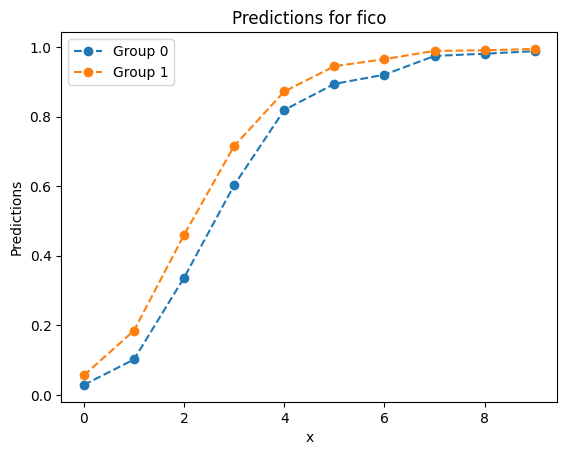

In [129]:
plot_prediction_model("fico", "sellf_tpr")

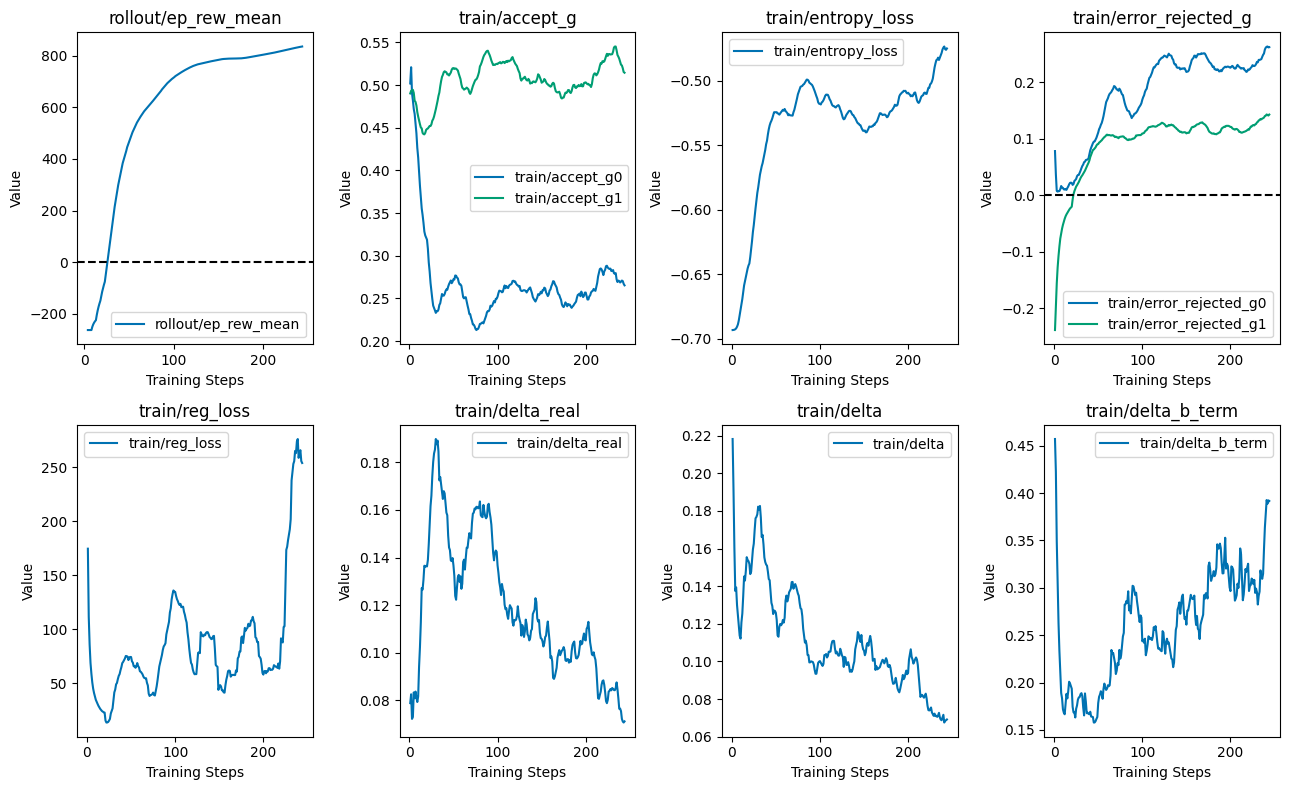

In [23]:
plot_sellf_terms("fico", "sellf_tpr")

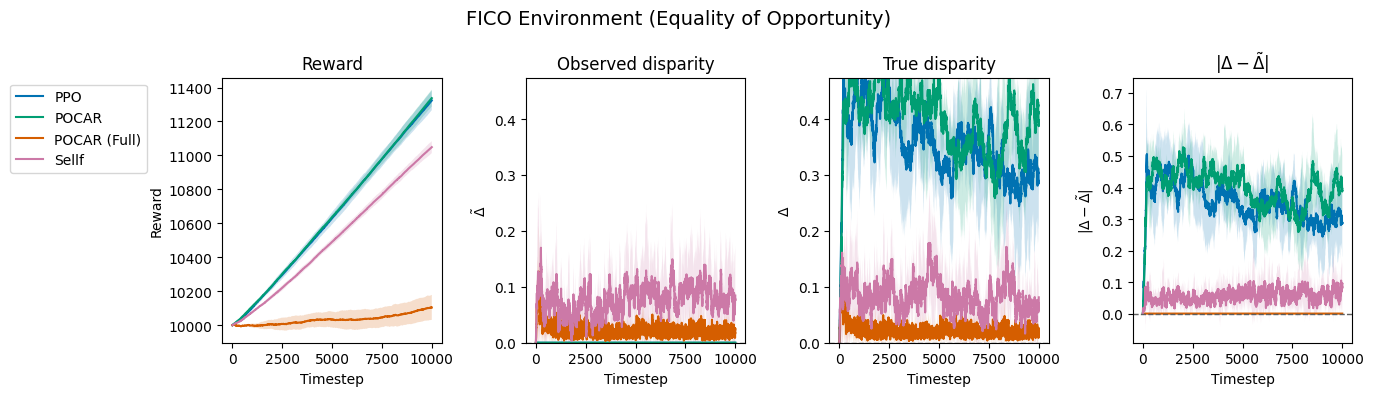

In [ ]:
methods = [
    "ppo_tpr",
    "pocar_tpr",
    "pocarfull_tpr",
    "sellf_tpr",
]
alg_names = {
    "sellf_tpr": "Sellf",
    "ppo_tpr": "PPO",
    "pocar_tpr": "POCAR",
    "pocarfull_tpr": "POCAR (Full)"
}

fig, axs = plot_results(
    "fico",
    methods,
    algs_names=alg_names,
    return_plot=True,
)

fig.suptitle("FICO Environment (Equality of Opportunity)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/fico_tpr_results.pdf", dpi = 300)

### fico acc

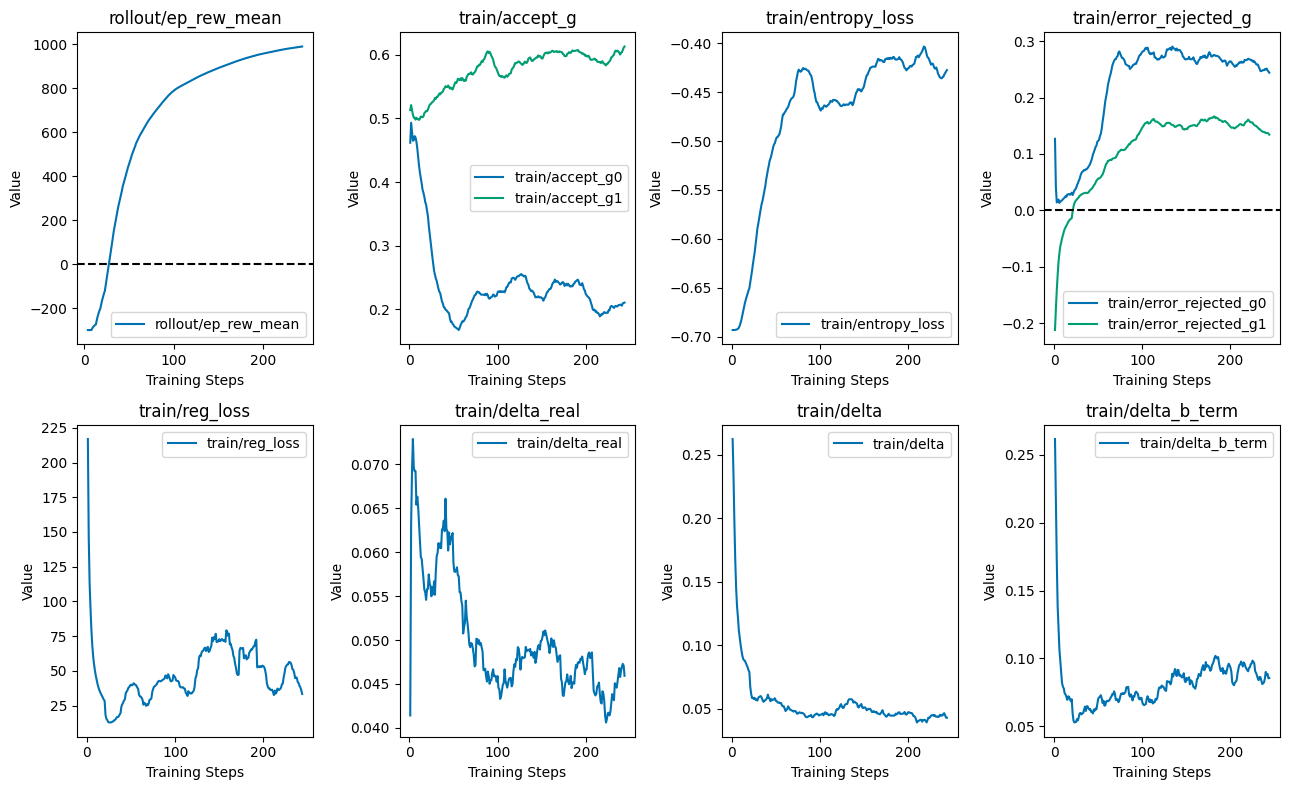

In [24]:
plot_sellf_terms("fico", "sellf_acc")

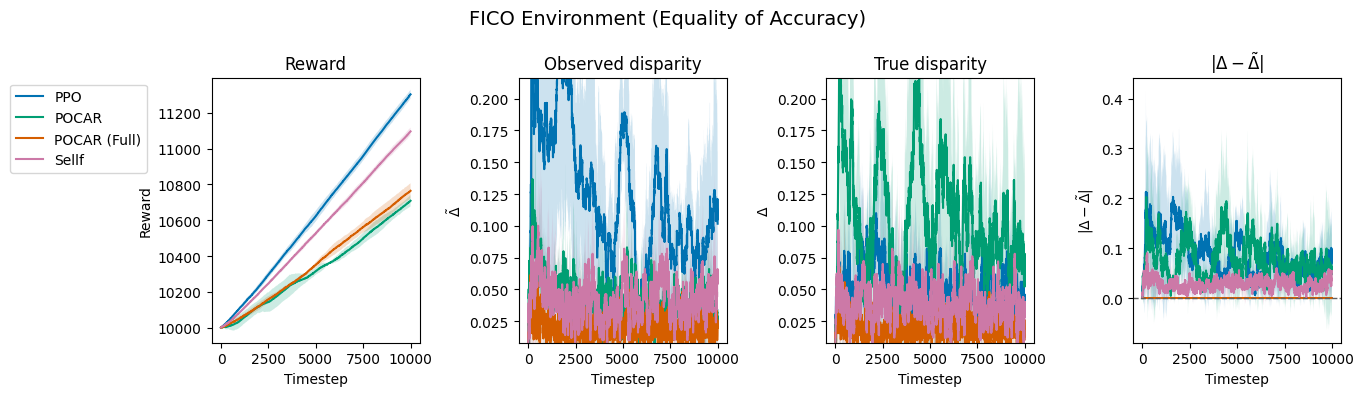

In [ ]:
methods = [
    "ppo_acc",
    "pocar_acc",
    "pocarfull_acc",
    "sellf_acc",
]
alg_names = {
    "sellf_acc": "Sellf",
    "ppo_acc": "PPO",
    "pocar_acc": "POCAR",
    "pocarfull_acc": "POCAR (Full)"
}

fig, axs = plot_results(
    "fico",
    methods,
    algs_names=alg_names,
    return_plot=True,
)

fig.suptitle("FICO Environment (Equality of Accuracy)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/fico_acc_results.pdf", dpi = 300)

### quali

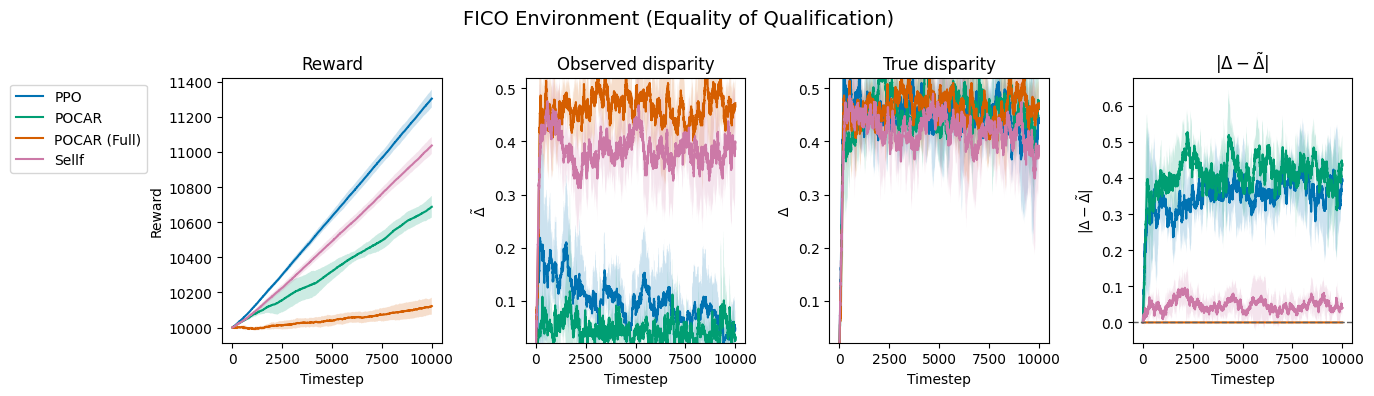

In [6]:
methods = [
    "ppo_quali",
    "pocar_quali",
    "pocarfull_quali",
    "sellf_quali",
]
alg_names = {
    "sellf_quali": "Sellf",
    "ppo_quali": "PPO",
    "pocar_quali": "POCAR",
    "pocarfull_quali": "POCAR (Full)"
}

fig, axs = plot_results(
    "fico",
    methods,
    algs_names=alg_names,
    return_plot=True,
)

fig.suptitle("FICO Environment (Equality of Qualification)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/fico_quali_results.pdf", dpi = 300)

## enem

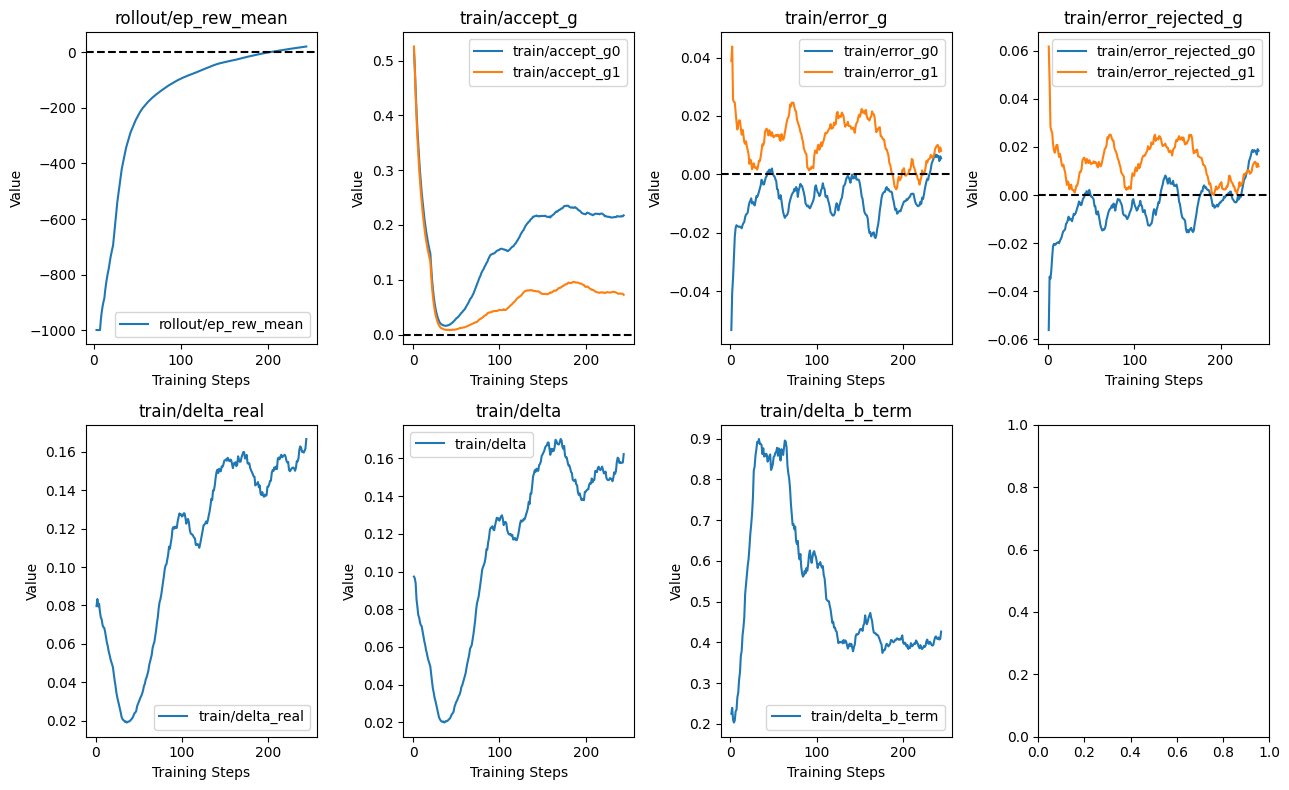

In [121]:
plot_sellf_terms("enem", "sellf_tpr")

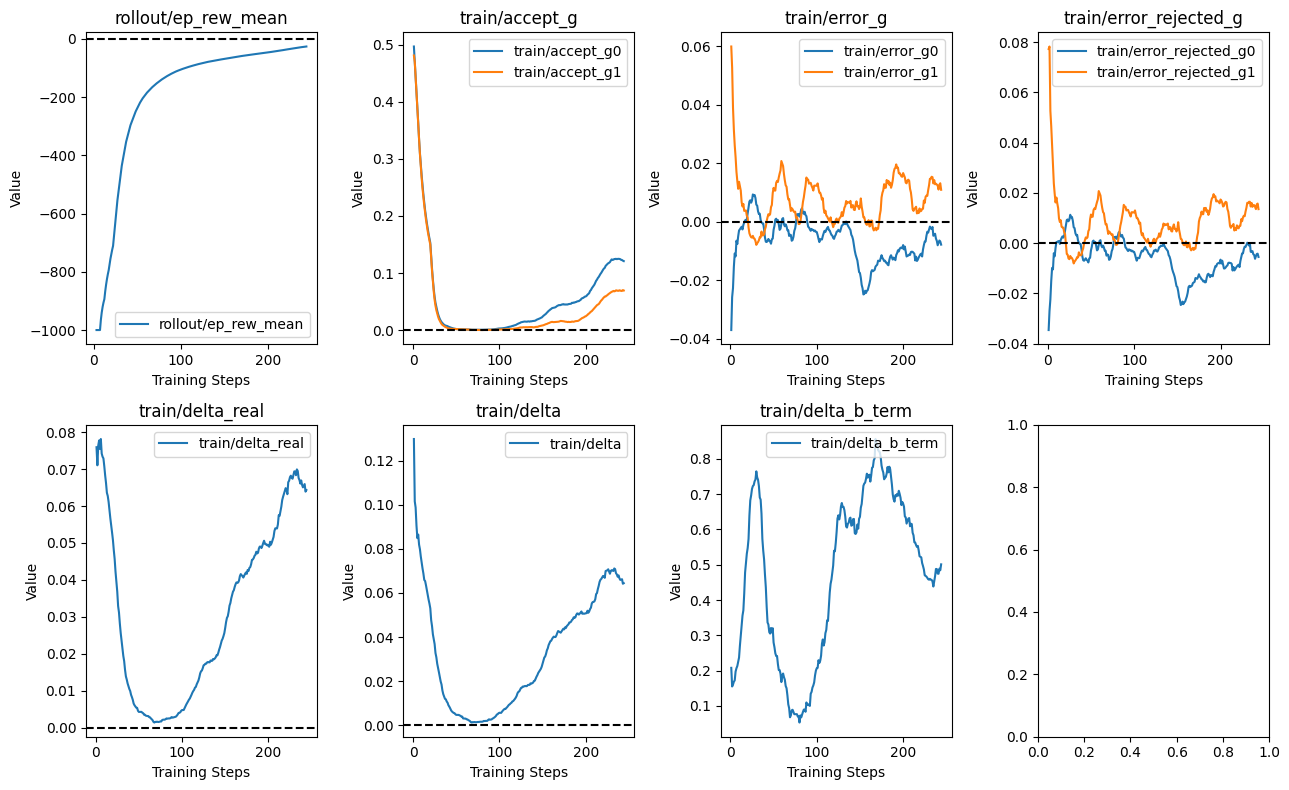

In [126]:
plot_sellf_terms("enem", "sellf_tpr")

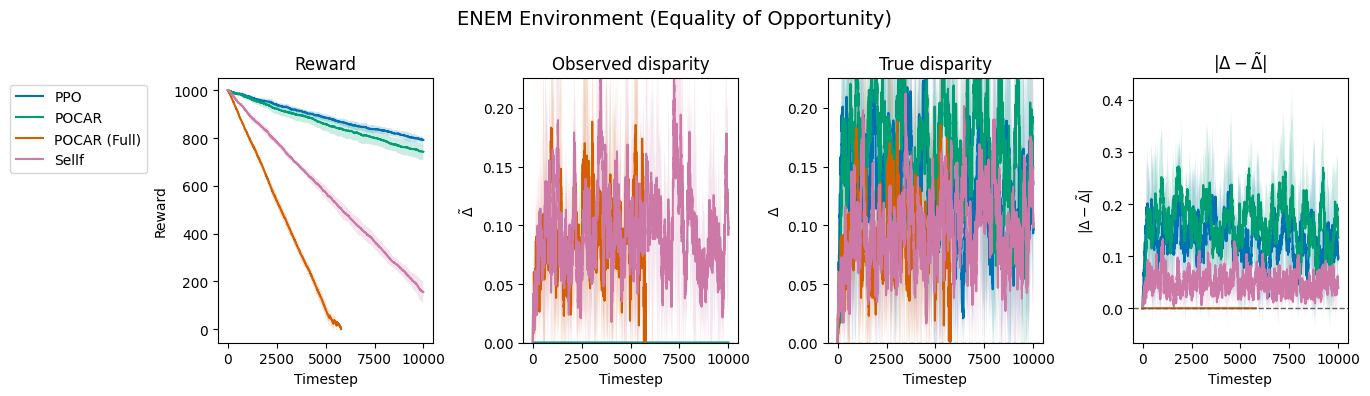

In [6]:
methods = [
    "ppo_tpr",
    "pocar_tpr",
    "pocarfull_tpr",
    "sellf_tpr",
]
alg_names = {
    "sellf_tpr": "Sellf",
    "ppo_tpr": "PPO",
    "pocar_tpr": "POCAR",
    "pocarfull_tpr": "POCAR (Full)"
}

fig, axs = plot_results(
    "enem",
    methods,
    algs_names=alg_names,
    return_plot=True,
)

fig.suptitle("ENEM Environment (Equality of Opportunity)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/enem_tpr_results.pdf", dpi = 300)

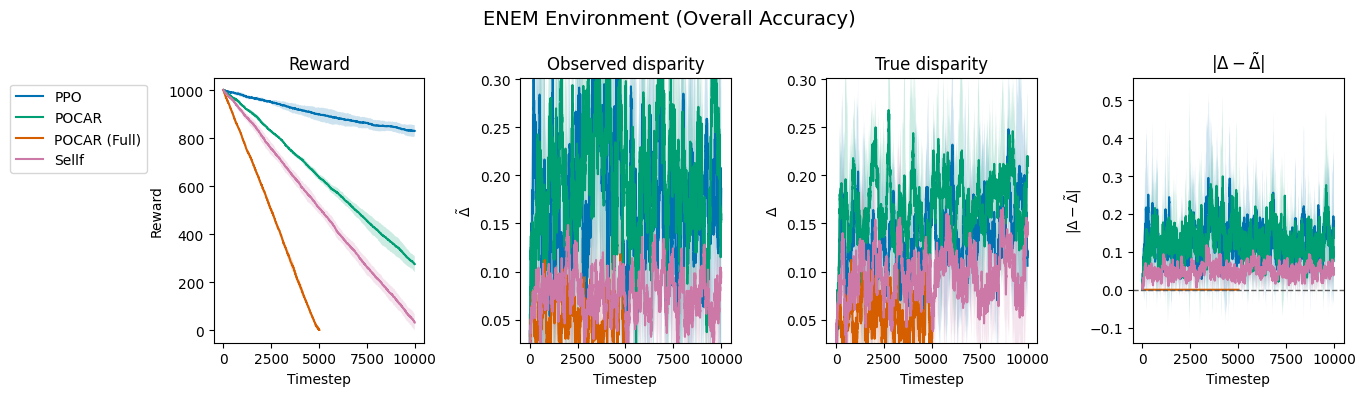

In [7]:
methods = [
    "ppo_acc",
    "pocar_acc",
    "pocarfull_acc",
    "sellf_acc",
]
alg_names = {
    "sellf_acc": "Sellf",
    "ppo_acc": "PPO",
    "pocar_acc": "POCAR",
    "pocarfull_acc": "POCAR (Full)"
}

fig, axs = plot_results(
    "enem",
    methods,
    algs_names=alg_names,
    return_plot=True,
)

fig.suptitle("ENEM Environment (Overall Accuracy)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/enem_acc_results.pdf", dpi = 300)

### qualification

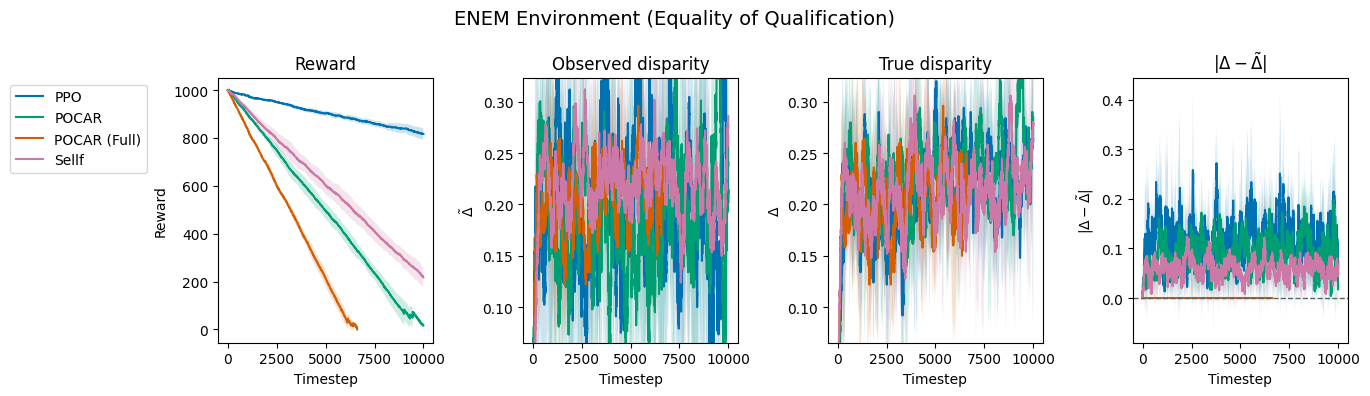

In [8]:
methods = [
    "ppo_quali",
    "pocar_quali",
    "pocarfull_quali",
    "sellf_quali",
]
alg_names = {
    "sellf_quali": "Sellf",
    "ppo_quali": "PPO",
    "pocar_quali": "POCAR",
    "pocarfull_quali": "POCAR (Full)"
}

fig, axs = plot_results(
    "enem",
    methods,
    algs_names=alg_names,
    return_plot=True,
)

fig.suptitle("ENEM Environment (Equality of Qualification)", fontsize=14)
plt.tight_layout()
plt.savefig("figures/enem_quali_results.pdf", dpi = 300)